In [52]:
# 
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import argparse

In [53]:
frame_num = 12

In [54]:
file_template_1 = f"/home/zrj/project/ori_v2v/streamv2v/vid2vid/output/self_attn_feats_SD/mid_block.attentions.0.transformer_blocks.0.attn1.processor.frame4.pt"
# 提取其中的hidden_states
hidden_states_1 = torch.load(file_template_1)["hidden_states"]
# 提取其中的query
query_1 = torch.load(file_template_1)["query"]
# 提取其中的key
key_1 = torch.load(file_template_1)["key"]
# 提取其中的value
value_1 = torch.load(file_template_1)["value"]


In [55]:
# 输出所有量的shape
print("hidden_states_1 shape:", hidden_states_1.shape)
print("query_1 shape:", query_1.shape)
print("key_1 shape:", key_1.shape)
print("value_1 shape:", value_1.shape)


hidden_states_1 shape: torch.Size([4, 120, 1280])
query_1 shape: torch.Size([4, 120, 1280])
key_1 shape: torch.Size([4, 120, 1280])
value_1 shape: torch.Size([4, 120, 1280])


In [56]:
file_template_bank = f"/home/zrj/project/ori_v2v/streamv2v/vid2vid/output/self_attn_bank/mid_block.attentions.0.transformer_blocks.0.attn1.processor.frame{frame_num}.pt"
# 提取其中的out_puts
outputs_bank = torch.load(file_template_bank)["outputs"]
# 提取其中的key
key_bank = torch.load(file_template_bank)["key"]
# 提取其中的value
value_bank = torch.load(file_template_bank)["value"]

In [57]:
# 打印尺寸
print("outputs_bank shape:", outputs_bank.shape)
print("key_bank shape:", key_bank.shape)
print("value_bank shape:", value_bank.shape)


outputs_bank shape: torch.Size([4, 120, 1280])
key_bank shape: torch.Size([4, 120, 1280])
value_bank shape: torch.Size([4, 120, 1280])


In [58]:
# 计算attn_map，即QK^T
attn_map = torch.matmul(query_1, key_bank.transpose(-2, -1))
print("attn_map shape:", attn_map.shape)
# 归一化
# attn_map = attn_map.softmax(dim=-1)
# print("attn_map shape:", attn_map.shape)

attn_map shape: torch.Size([4, 120, 120])


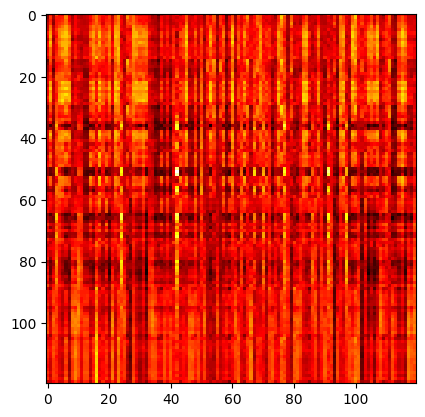

In [59]:
# 可视化attn_map，热图表示注意力权重
plt.imshow(attn_map[0].detach().numpy(), cmap='hot', interpolation='nearest')
plt.show()